In [1]:
import re
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

print("Imports OK")

Imports OK


In [2]:
from pathlib import Path

data_path = Path("train_data.csv")

df_raw = pd.read_csv(data_path)
print("Loaded:", data_path)
print("Shape:", df_raw.shape)
df_raw.head()

Loaded: train_data.csv
Shape: (54000, 14)


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,geocode_status,latitude,longitude,geocode_provider,dublin_district
0,30/09/2016,"28 BRACKEN COURT, DONNYBROOK, CORK",Cork,NaN,"€181,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN
1,20/12/2016,"2 AN CLOCHAR, CONVENT RD, DONERAILE",Cork,NaN,"€50,152.49",No,Yes,New Dwelling house /Apartment,less than 38 sq metres,NaN,NaN,NaN,NaN,NaN
2,28/09/2016,"Apartment 7 The Court, Clonattin, Gorey",Wexford,NaN,"€62,171.81",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,NaN,NaN,NaN,NaN,NaN
3,16/09/2016,"6 Monalin, Wicklow Hills, Newtownmountkennedy",Wicklow,NaN,"€223,348.00",No,Yes,New Dwelling house /Apartment,greater than or equal to 38 sq metres and less...,NaN,NaN,NaN,NaN,NaN
4,29/01/2016,"18 Lislea, Frascati Park, Blackrock",Dublin,NaN,"€310,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,ok_mapbox_relaxed,53.299848,-6.182849,mapbox,27


In [3]:
from dataclasses import dataclass, field

@dataclass
class DQLog:
    steps: list = field(default_factory=list)

    def add(self, step: str, before_shape, after_shape, notes: str = ""):
        br, bc = before_shape
        ar, ac = after_shape
        self.steps.append({
            "step": step,
            "rows_before": br, "rows_after": ar, "rows_delta": ar - br,
            "cols_before": bc, "cols_after": ac, "cols_delta": ac - bc,
            "notes": notes
        })

    def to_frame(self):
        return pd.DataFrame(self.steps)

log = DQLog()
df = df_raw.copy()

# --- Text normalization ---
text_cols = [c for c in df.columns if df[c].dtype == "object"]
for c in text_cols:
    df[c] = df[c].apply(lambda x: re.sub(r"\s+", " ", str(x).strip()) if pd.notna(x) else x)

# --- Date parsing ---
date_col = "Date of Sale (dd/mm/yyyy)"
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")

# --- Price parsing ---
price_col = "Price (€)"
df[price_col] = pd.to_numeric(
    df[price_col].astype(str).str.replace("€", "", regex=False).str.replace(",", "", regex=False),
    errors="coerce"
)

# --- Time features ---
df["Sale Year"]  = df[date_col].dt.year
df["Sale Month"] = df[date_col].dt.month

# --- is_apartment ---
addr_col = "Address"
df["is_apartment"] = df[addr_col].str.contains(
    r"\b(apartment|apt|unit|flat)\b", case=False, na=False
).astype(int)

# --- location feature ---
def build_location(row):
    county = str(row["County"]).strip() if pd.notna(row["County"]) else ""
    district = row["dublin_district"]
    if county == "Dublin":
        if pd.notna(district) and str(district).strip() != "":
            return "Dublin " + str(district).strip()
        else:
            return "Dublin Other"
    else:
        return county if county else "Unknown"

df["location"] = df.apply(build_location, axis=1)

print("location value counts (top 20):")
print(df["location"].value_counts().head(20))
print("\nSample rows:")
display(df[["County", "dublin_district", "location"]].drop_duplicates().head(20))

location value counts (top 20):
location
Cork         5975
Kildare      2926
Galway       2600
Meath        2325
Limerick     2063
Dublin 26    2000
Wicklow      1924
Wexford      1883
Tipperary    1538
Louth        1534
Kerry        1517
Waterford    1482
Dublin 27    1434
Donegal      1397
Dublin 15    1393
Mayo         1255
Clare        1187
Westmeath    1043
Dublin 25     960
Dublin 24     952
Name: count, dtype: int64

Sample rows:


/var/folders/lm/1wz6n56157b9hqw0yth0p3j40000gn/T/ipykernel_95577/3399918764.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_apartment"] = df[addr_col].str.contains(


,County,dublin_district,location
0,Cork,NaN,Cork
2,Wexford,NaN,Wexford
3,Wicklow,NaN,Wicklow
4,Dublin,27,Dublin 27
5,Kildare,NaN,Kildare
6,Dublin,15,Dublin 15
7,Dublin,26,Dublin 26
9,Dublin,3,Dublin 3
12,Clare,NaN,Clare
14,Dublin,16,Dublin 16


In [4]:
# --- Drop duplicates ---
before = df.shape
df = df.drop_duplicates()
after = df.shape
log.add("Drop duplicate rows", before, after, f"removed={before[0]-after[0]}")
print(f"Duplicates removed: {before[0]-after[0]}")

# --- Filter invalid core rows ---
before = df.shape
reject_mask = (
    df[price_col].isna() | (df[price_col] <= 0) |
    df[date_col].isna() |
    df["County"].isna() | (df["County"].astype(str).str.strip() == "")
)
rejected = int(reject_mask.sum())
df = df.loc[~reject_mask].copy()
after = df.shape
log.add("Filter invalid core rows (price/date/county)", before, after, f"rejected={rejected}")
print(f"Rejected rows: {rejected}")
print(f"Shape after: {df.shape}")

Duplicates removed: 9
Rejected rows: 0
Shape after: (53991, 18)


In [5]:
# --- VAT adjustment ---
before = df.shape
VAT_RATE = 0.135

cond = (
    (df["Description of Property"].astype(str).str.strip() == "New Dwelling house /Apartment") &
    (df["VAT Exclusive"].astype(str).str.strip().str.lower() == "yes") &
    (df[price_col].notna())
)

df["Price_Adjusted_VAT"] = df[price_col].copy()
df.loc[cond, "Price_Adjusted_VAT"] = df.loc[cond, price_col] * (1 + VAT_RATE)
df["vat_adjusted_flag"] = cond.astype(int)

after = df.shape
log.add("VAT adjustment", before, after, f"affected_rows={int(cond.sum())}")
print(f"VAT adjusted rows: {int(cond.sum())}")

# --- Price clamping (5%-95%) ---
before = df.shape
p05 = df["Price_Adjusted_VAT"].quantile(0.05)
p95 = df["Price_Adjusted_VAT"].quantile(0.95)

df["Price_Adjusted_VAT_Clamped"] = df["Price_Adjusted_VAT"].clip(lower=p05, upper=p95)

clamped = int((df["Price_Adjusted_VAT_Clamped"] != df["Price_Adjusted_VAT"]).sum())
after = df.shape
log.add("Price clamping p05-p95", before, after, f"p05={p05:.0f}, p95={p95:.0f}, clamped_rows={clamped}")
print(f"p05={p05:.0f}, p95={p95:.0f}, clamped_rows={clamped}")
print(f"Shape after: {df.shape}")

VAT adjusted rows: 9513
p05=60000, p95=721138, clamped_rows=5333
Shape after: (53991, 21)


In [6]:
# --- Select final columns ---
before = df.shape

final_cols = [
    date_col,                        # 日期（备用）
    "Sale Year",                     # 销售年份
    "Sale Month",                    # 销售月份
    "is_apartment",                  # 是否公寓
    "location",                      # 行政区划特征
    "Description of Property",       # 房产类型
    "Not Full Market Price",         # 是否非全市价
    "Price_Adjusted_VAT_Clamped",    # 最终目标价格
    "vat_adjusted_flag",             # VAT调整标记
]

# Keep only columns that exist
final_cols = [c for c in final_cols if c in df.columns]
df = df[final_cols].copy()

after = df.shape
log.add("Select final columns", before, after)
print(f"Final columns ({len(final_cols)}): {final_cols}")
print(f"Shape after: {df.shape}")

# --- Fill missing values ---
before = df.shape

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c != date_col]

for c in cat_cols:
    df[c] = df[c].fillna("Unknown")

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

after = df.shape
log.add("Fill missing values", before, after)

print(f"\nRemaining missing values:")
print(df.isna().sum())

Final columns (9): ['Date of Sale (dd/mm/yyyy)', 'Sale Year', 'Sale Month', 'is_apartment', 'location', 'Description of Property', 'Not Full Market Price', 'Price_Adjusted_VAT_Clamped', 'vat_adjusted_flag']
Shape after: (53991, 9)

Remaining missing values:
Date of Sale (dd/mm/yyyy)     0
Sale Year                     0
Sale Month                    0
is_apartment                  0
location                      0
Description of Property       0
Not Full Market Price         0
Price_Adjusted_VAT_Clamped    0
vat_adjusted_flag             0
dtype: int64


In [7]:
# --- Processing log ---
print("=== DQ Processing Log ===")
display(log.to_frame())

# --- Final preview ---
print(f"\nFinal shape: {df.shape}")
print(f"\nlocation distribution (top 20):")
print(df["location"].value_counts().head(20))
print(f"\nDescription of Property distribution:")
print(df["Description of Property"].value_counts())
print(f"\nNot Full Market Price distribution:")
print(df["Not Full Market Price"].value_counts())
display(df.sample(5, random_state=42))

=== DQ Processing Log ===


,step,rows_before,rows_after,rows_delta,cols_before,cols_after,cols_delta,notes
0,Drop duplicate rows,54000,53991,-9,18,18,0,removed=9
1,Filter invalid core rows (price/date/county),53991,53991,0,18,18,0,rejected=0
2,VAT adjustment,53991,53991,0,18,20,2,affected_rows=9513
3,Price clamping p05-p95,53991,53991,0,20,21,1,"p05=60000, p95=721138, clamped_rows=5333"
4,Select final columns,53991,53991,0,21,9,-12,
5,Fill missing values,53991,53991,0,9,9,0,



Final shape: (53991, 9)

location distribution (top 20):
location
Cork         5973
Kildare      2925
Galway       2598
Meath        2325
Limerick     2063
Dublin 26    2000
Wicklow      1924
Wexford      1883
Tipperary    1538
Louth        1534
Kerry        1517
Waterford    1482
Dublin 27    1434
Donegal      1396
Dublin 15    1393
Mayo         1253
Clare        1187
Westmeath    1043
Dublin 25     960
Dublin 24     952
Name: count, dtype: int64

Description of Property distribution:
Description of Property
Second-Hand Dwelling house /Apartment    44324
New Dwelling house /Apartment             9664
Teach/Árasán Cónaithe Atháimhe               3
Name: count, dtype: int64

Not Full Market Price distribution:
Not Full Market Price
No     51144
Yes     2847
Name: count, dtype: int64


,Date of Sale (dd/mm/yyyy),Sale Year,Sale Month,is_apartment,location,Description of Property,Not Full Market Price,Price_Adjusted_VAT_Clamped,vat_adjusted_flag
45584,2023-09-15,2023,9,0,Westmeath,Second-Hand Dwelling house /Apartment,No,299950.0,0
21937,2019-04-26,2019,4,0,Cavan,Second-Hand Dwelling house /Apartment,No,130000.0,0
1319,2016-12-20,2016,12,0,Dublin 13,Second-Hand Dwelling house /Apartment,No,209000.0,0
4640,2016-07-11,2016,7,0,Galway,Second-Hand Dwelling house /Apartment,No,93000.0,0
46394,2023-06-14,2023,6,0,Wexford,Second-Hand Dwelling house /Apartment,No,102500.0,0


In [8]:
out_path = "train_data_clean.csv"
df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved: train_data_clean.csv
Shape: (53991, 9)
Columns: ['Date of Sale (dd/mm/yyyy)', 'Sale Year', 'Sale Month', 'is_apartment', 'location', 'Description of Property', 'Not Full Market Price', 'Price_Adjusted_VAT_Clamped', 'vat_adjusted_flag']


In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
print("Imports OK")

Imports OK


In [10]:
df = pd.read_csv("train_data_clean.csv")
print("Loaded: train_data_clean.csv")
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

Loaded: train_data_clean.csv
Shape: (53991, 9)


,Date of Sale (dd/mm/yyyy),Sale Year,Sale Month,is_apartment,location,Description of Property,Not Full Market Price,Price_Adjusted_VAT_Clamped,vat_adjusted_flag
0,2016-09-30,2016,9,0,Cork,Second-Hand Dwelling house /Apartment,No,181000.00000,0
1,2016-12-20,2016,12,0,Cork,New Dwelling house /Apartment,No,60000.00000,1
2,2016-09-28,2016,9,1,Wexford,New Dwelling house /Apartment,No,70565.00435,1
3,2016-09-16,2016,9,0,Wicklow,New Dwelling house /Apartment,No,253499.98000,1
4,2016-01-29,2016,1,0,Dublin 27,Second-Hand Dwelling house /Apartment,No,310000.00000,0


,dtype
Date of Sale (dd/mm/yyyy),str
Sale Year,int64
Sale Month,int64
is_apartment,int64
location,str
Description of Property,str
Not Full Market Price,str
Price_Adjusted_VAT_Clamped,float64
vat_adjusted_flag,int64


In [11]:
# --- Define features and target ---
target = "Price_Adjusted_VAT_Clamped"

# Numeric features
num_features = ["Sale Year", "Sale Month", "is_apartment", "vat_adjusted_flag"]

# Categorical features for one-hot encoding
cat_features = ["location", "Description of Property", "Not Full Market Price"]

X_num = df[num_features].copy()
X_cat = df[cat_features].copy()
y = df[target].copy()

# --- One-Hot Encoding ---
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_encoded = encoder.fit_transform(X_cat)
cat_col_names = encoder.get_feature_names_out(cat_features)

X_cat_df = pd.DataFrame(X_cat_encoded, columns=cat_col_names, index=df.index)

# --- Combine ---
X = pd.concat([X_num, X_cat_df], axis=1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNumeric features: {num_features}")
print(f"\nOne-hot encoded categories: {len(cat_col_names)} columns")
print(f"  location categories: {df['location'].nunique()}")
print(f"  Description of Property categories: {df['Description of Property'].nunique()}")
print(f"  Not Full Market Price categories: {df['Not Full Market Price'].nunique()}")

X shape: (53991, 60)
y shape: (53991,)

Numeric features: ['Sale Year', 'Sale Month', 'is_apartment', 'vat_adjusted_flag']

One-hot encoded categories: 56 columns
  location categories: 51
  Description of Property categories: 3
  Not Full Market Price categories: 2


In [12]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# --- Linear Regression ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- Predictions ---
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# --- Metrics ---
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print(f"\n{'':20s} {'Train':>12s} {'Test':>12s}")
print(f"{'RMSE':20s} {rmse_train:>12.0f} {rmse_test:>12.0f}")
print(f"{'R²':20s} {r2_train:>12.4f} {r2_test:>12.4f}")

Train: (43192, 60), Test: (10799, 60)

                            Train         Test
RMSE                       126707       126864
R²                         0.4732       0.4702


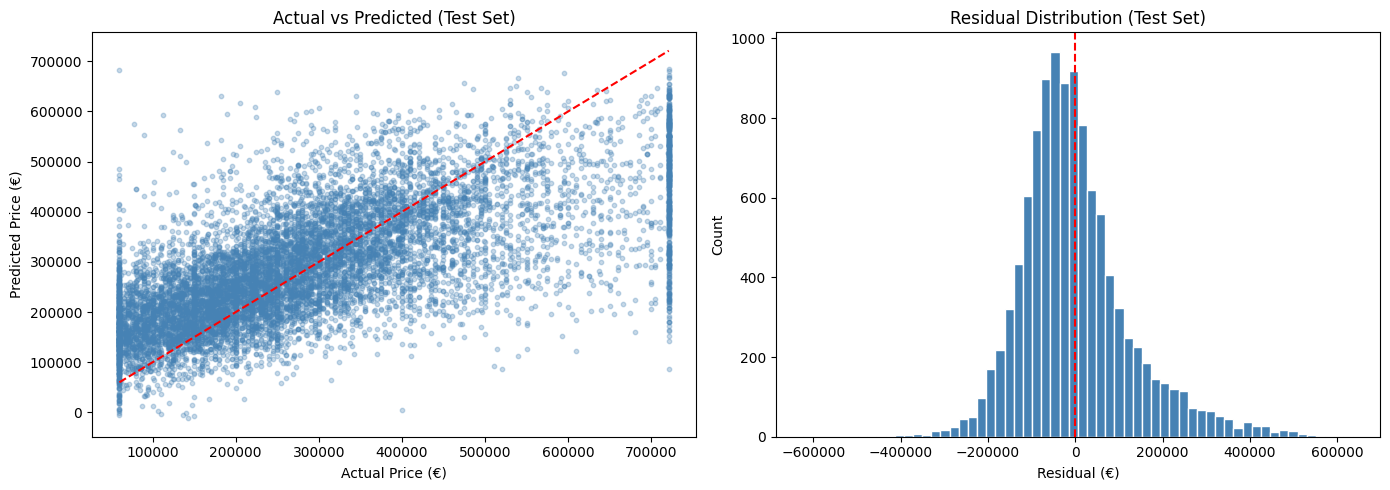

Mean residual:   -1,296
Std  residual:   126,863


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Actual vs Predicted ---
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel("Actual Price (€)")
axes[0].set_ylabel("Predicted Price (€)")
axes[0].set_title("Actual vs Predicted (Test Set)")

# --- Residuals distribution ---
residuals = y_test - y_pred_test
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Residual (€)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution (Test Set)")

plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():,.0f}")
print(f"Std  residual:   {residuals.std():,.0f}")

Top 10 正系数（价格推高因素）:


,feature,coefficient
34,location_Dublin Other,311387.789521
29,location_Dublin 6,259133.512888
14,location_Dublin 14,232894.008125
30,location_Dublin 6W,224225.480301
27,location_Dublin 4,220761.455664
25,location_Dublin 27,211233.102691
18,location_Dublin 18,182606.044313
16,location_Dublin 16,176950.023113
19,location_Dublin 2,148615.811482
26,location_Dublin 3,116824.067114



Top 10 负系数（价格压低因素）:


,feature,coefficient
47,location_Offaly,-126118.095584
50,location_Tipperary,-129541.414132
49,location_Sligo,-140016.666538
46,location_Monaghan,-142524.531623
5,location_Cavan,-146747.589406
44,location_Mayo,-155145.980283
42,location_Longford,-161213.652061
8,location_Donegal,-162699.010408
48,location_Roscommon,-166590.764340
40,location_Leitrim,-171095.981894


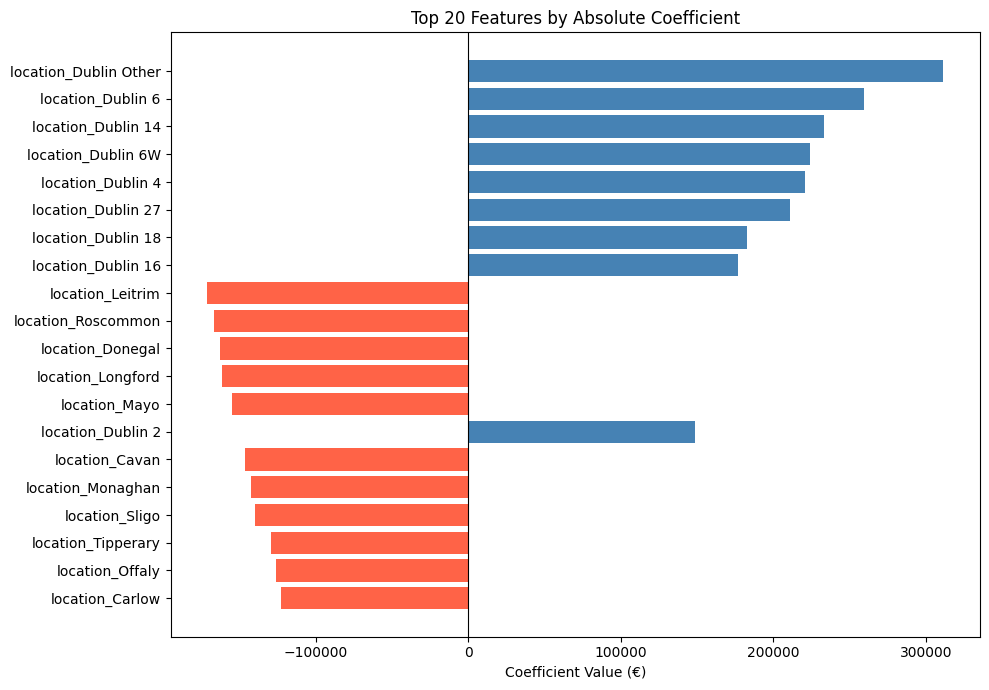

In [14]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

print("Top 10 正系数（价格推高因素）:")
display(coef_df.head(10))

print("\nTop 10 负系数（价格压低因素）:")
display(coef_df.tail(10))

# --- Plot top 20 by absolute value ---
top20 = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(10, 7))
colors = ["steelblue" if v > 0 else "tomato" for v in top20["coefficient"]]
plt.barh(top20["feature"], top20["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient Value (€)")
plt.title("Top 20 Features by Absolute Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
coef_df.to_csv("linear_regression_coefficients.csv", index=False)
print("Saved: linear_regression_coefficients.csv")
print(f"\nIntercept: {model.intercept_:,.0f}")
print(f"\nFull coefficient table:")
display(coef_df)

Saved: linear_regression_coefficients.csv

Intercept: -31,871,806

Full coefficient table:


,feature,coefficient
34,location_Dublin Other,311387.789521
29,location_Dublin 6,259133.512888
14,location_Dublin 14,232894.008125
30,location_Dublin 6W,224225.480301
27,location_Dublin 4,220761.455664
25,location_Dublin 27,211233.102691
18,location_Dublin 18,182606.044313
16,location_Dublin 16,176950.023113
19,location_Dublin 2,148615.811482
26,location_Dublin 3,116824.067114


In [16]:
from sklearn.metrics import mean_absolute_error

# --- Load test data ---
df_test_raw = pd.read_csv("test_data.csv")
print("Loaded: test_data.csv")
print("Shape:", df_test_raw.shape)

df_test = df_test_raw.copy()

# --- Text normalization ---
text_cols_test = [c for c in df_test.columns if df_test[c].dtype == "object"]
for c in text_cols_test:
    df_test[c] = df_test[c].apply(lambda x: re.sub(r"\s+", " ", str(x).strip()) if pd.notna(x) else x)

# --- Date parsing ---
df_test[date_col] = pd.to_datetime(df_test[date_col], dayfirst=True, errors="coerce")

# --- Price parsing ---
df_test[price_col] = pd.to_numeric(
    df_test[price_col].astype(str).str.replace("€", "", regex=False).str.replace(",", "", regex=False),
    errors="coerce"
)

# --- Time features ---
df_test["Sale Year"]  = df_test[date_col].dt.year
df_test["Sale Month"] = df_test[date_col].dt.month

# --- is_apartment ---
df_test["is_apartment"] = df_test["Address"].str.contains(
    r"apartment|apt|unit|flat", case=False, na=False
).astype(int)

# --- location feature ---
df_test["location"] = df_test.apply(build_location, axis=1)

# --- Drop duplicates + filter invalid rows ---
df_test = df_test.drop_duplicates()
reject_mask_test = (
    df_test[price_col].isna() | (df_test[price_col] <= 0) |
    df_test[date_col].isna() |
    df_test["County"].isna() | (df_test["County"].astype(str).str.strip() == "")
)
print(f"Rejected rows: {int(reject_mask_test.sum())}")
df_test = df_test.loc[~reject_mask_test].copy()

# --- VAT adjustment ---
cond_test = (
    (df_test["Description of Property"].astype(str).str.strip() == "New Dwelling house /Apartment") &
    (df_test["VAT Exclusive"].astype(str).str.strip().str.lower() == "yes") &
    (df_test[price_col].notna())
)
df_test["Price_Adjusted_VAT"] = df_test[price_col].copy()
df_test.loc[cond_test, "Price_Adjusted_VAT"] = df_test.loc[cond_test, price_col] * (1 + VAT_RATE)
df_test["vat_adjusted_flag"] = cond_test.astype(int)

# --- Price clamping (使用训练集的 p05/p95) ---
df_test["Price_Adjusted_VAT_Clamped"] = df_test["Price_Adjusted_VAT"].clip(lower=p05, upper=p95)

print(f"Test shape after cleaning: {df_test.shape}")
display(df_test.head())

Loaded: test_data.csv
Shape: (10000, 14)
Rejected rows: 0
Test shape after cleaning: (9999, 21)


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,geocode_status,latitude,longitude,geocode_provider,dublin_district,Sale Year,Sale Month,is_apartment,location,Price_Adjusted_VAT,vat_adjusted_flag,Price_Adjusted_VAT_Clamped
0,2025-12-15,"BALLYHOO, SCREEN, ENNISCORTHY",Wexford,Y21Y5P2,375000.00,No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN,2025,12,0,Wexford,375000.0000,0,375000.0000
1,2025-11-11,"RATHREIGH, ARDAGH, CO. LIMERICK",Limerick,V42CF72,152000.00,No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN,2025,11,0,Limerick,152000.0000,0,152000.0000
2,2025-12-02,"36 Woodword Court, Glencarin Gate, Murphystown...",Dublin,NaN,511150.12,No,Yes,New Dwelling house /Apartment,NaN,ok_mapbox_strict,53.263504,-6.207458,mapbox,18,2025,12,0,Dublin 18,580155.3862,1,580155.3862
3,2025-12-10,"FRANKFORD, ENNISCRONE, CO SLIGO",Sligo,F26EW70,200000.00,Yes,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN,2025,12,0,Sligo,200000.0000,0,200000.0000
4,2025-02-28,"100 MAIN STREET, BALLYBAY, COUNTY MONAGHAN",Monaghan,A75WV38,43500.00,No,No,Second-Hand Dwelling house /Apartment,NaN,NaN,NaN,NaN,NaN,NaN,2025,2,0,Monaghan,43500.0000,0,60000.0000


In [17]:
# --- Build test features ---
X_test_num = df_test[num_features].copy()
X_test_cat = df_test[cat_features].copy()

# 使用训练集的 encoder（不重新fit）
X_test_cat_encoded = encoder.transform(X_test_cat)
X_test_cat_df = pd.DataFrame(X_test_cat_encoded, columns=cat_col_names, index=df_test.index)

X_test_final = pd.concat([X_test_num, X_test_cat_df], axis=1)
y_test_final = df_test["Price_Adjusted_VAT_Clamped"]

print(f"X_test shape: {X_test_final.shape}")
print(f"y_test shape: {y_test_final.shape}")

# --- Predict ---
y_pred_final = model.predict(X_test_final)

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
mae  = mean_absolute_error(y_test_final, y_pred_final)
r2   = r2_score(y_test_final, y_pred_final)

print(f"\n=== Test Set Evaluation ===")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")

X_test shape: (9999, 60)
y_test shape: (9999,)

=== Test Set Evaluation ===
R²:   0.3976
MAE:  104,861 €
RMSE: 136,947 €


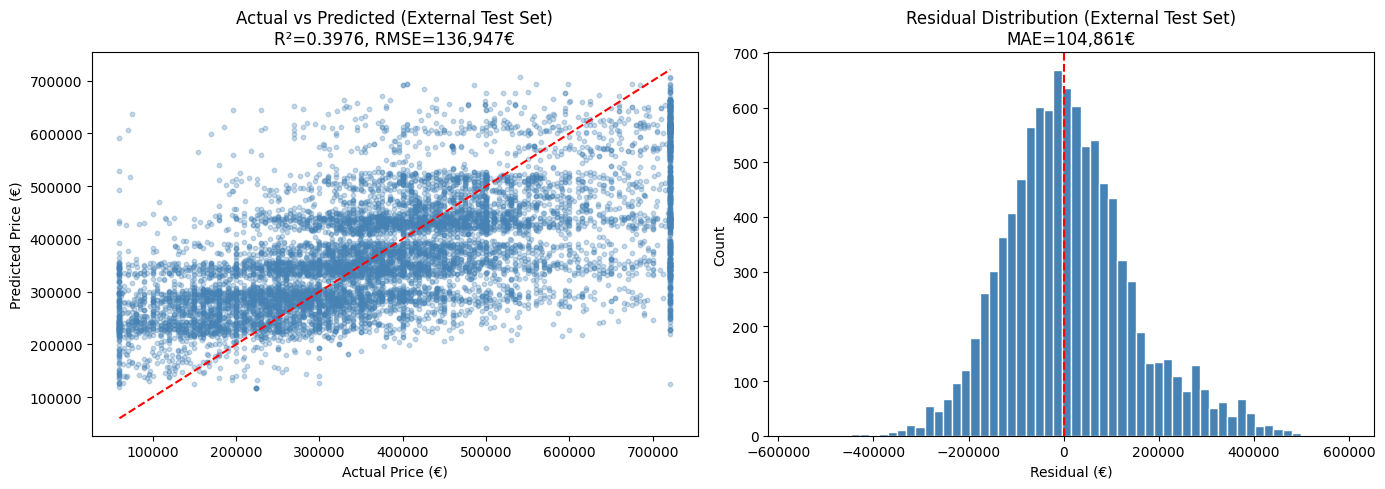

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Actual vs Predicted ---
axes[0].scatter(y_test_final, y_pred_final, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test_final.min(), y_test_final.max()],
             [y_test_final.min(), y_test_final.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel("Actual Price (€)")
axes[0].set_ylabel("Predicted Price (€)")
axes[0].set_title(f"Actual vs Predicted (External Test Set)\nR²={r2:.4f}, RMSE={rmse:,.0f}€")

# --- Residuals distribution ---
residuals_final = y_test_final - y_pred_final
axes[1].hist(residuals_final, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Residual (€)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution (External Test Set)\nMAE={mae:,.0f}€")

plt.tight_layout()
plt.show()